In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('historical_data.csv')

In [ ]:
print(df.shape)
print(df.describe())
print(df.isna().sum())
print(df.duplicated().sum())

(211224, 16)
       Execution Price   Size Tokens      Size USD  Start Position  \
count    211224.000000  2.112240e+05  2.112240e+05    2.112240e+05   
mean      11414.723350  4.623365e+03  5.639451e+03   -2.994625e+04   
std       29447.654868  1.042729e+05  3.657514e+04    6.738074e+05   
min           0.000005  8.740000e-07  0.000000e+00   -1.433463e+07   
25%           4.854700  2.940000e+00  1.937900e+02   -3.762311e+02   
50%          18.280000  3.200000e+01  5.970450e+02    8.472793e+01   
75%         101.580000  1.879025e+02  2.058960e+03    9.337278e+03   
max      109004.000000  1.582244e+07  3.921431e+06    3.050948e+07   

          Closed PnL      Order ID            Fee      Trade ID     Timestamp  
count  211224.000000  2.112240e+05  211224.000000  2.112240e+05  2.112240e+05  
mean       48.749001  6.965388e+10       1.163967  5.628549e+14  1.737744e+12  
std       919.164828  1.835753e+10       6.758854  3.257565e+14  8.689920e+09  
min   -117990.104100  1.732711e+08  

In [ ]:
print (df.columns)
print(df.isnull().sum())

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [ ]:
df2 = pd.read_csv('fear_greed_index.csv')

In [ ]:
print(df2.shape)
print(df2.describe())
print(df2.isna().sum())

(2644, 4)
          timestamp        value
count  2.644000e+03  2644.000000
mean   1.631899e+09    46.981089
std    6.597967e+07    21.827680
min    1.517463e+09     5.000000
25%    1.574811e+09    28.000000
50%    1.631900e+09    46.000000
75%    1.688989e+09    66.000000
max    1.746164e+09    95.000000
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [ ]:
print(df2.duplicated().sum())
print(df2.columns)
print(df2.isnull().sum())

0
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [ ]:
# for trader data
df['date'] = pd.to_datetime(df['Timestamp'], unit='ms').dt.date
# for greed/fear index
df2['date'] = pd.to_datetime(df2['date']).dt.date

In [ ]:
df = df[['Account', 'Coin', 'Execution Price', 'Size USD', 'Side',
         'Closed PnL', 'date']]

df2 = df2[['date', 'classification', 'value']]

In [ ]:
merged = pd.merge(df, df2, on='date', how='inner')
print(merged.shape)

(184263, 9)


In [ ]:
merged['profit_flag'] = (merged['Closed PnL'] > 0).astype(int)

In [ ]:
merged['loss_flag'] = (merged['Closed PnL'] < 0).astype(int)

In [ ]:
summary = merged.groupby('classification').agg({
    'Closed PnL': 'mean',
    'profit_flag': 'mean',
    'Size USD': 'mean'
}).reset_index()

print(summary)

  classification  Closed PnL  profit_flag     Size USD
0  Extreme Greed   25.418772     0.490089  5660.265764
1           Fear   50.047622     0.415146  5259.977837
2          Greed   87.894859     0.446471  3182.883845
3        Neutral   22.229713     0.317182  3058.848110


In [ ]:
print(merged['classification'].value_counts())

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


In [ ]:
print(merged[['Closed PnL', 'value']].corr())

            Closed PnL     value
Closed PnL    1.000000  0.011132
value         0.011132  1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

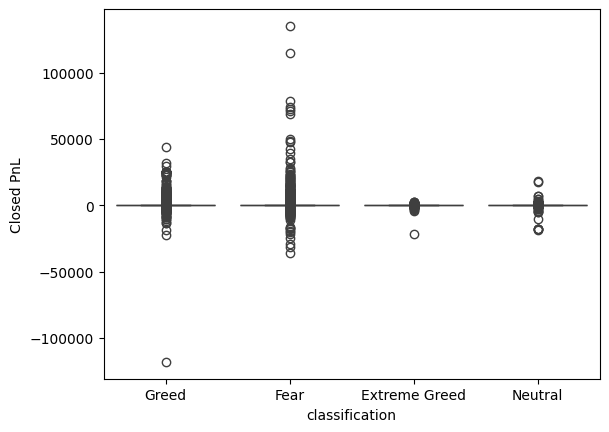

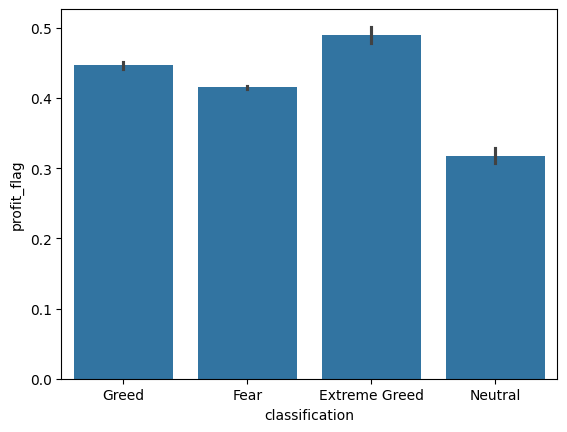

In [ ]:
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.show()

sns.barplot(x='classification', y='profit_flag', data=merged)
plt.show()

Graph 1 shows:

1. Fear and Greed phases show much higher variability in profits and losses, indicating more volatile trading outcomes.

2. Extreme Greed has tightly clustered PnL near zero, suggesting smaller, more consistent but lower-profit trades.

Graph 2 shows:

1. Extreme Greed has the highest win rate, meaning traders win more frequently in these conditions.

2. Neutral sentiment has the lowest win rate, indicating poor trading performance when the market lacks direction.

In [ ]:
merged.groupby(['classification', 'Side'])['Closed PnL'].mean()

classification  Side
Extreme Greed   BUY      25.578564
                SELL     25.268770
Fear            BUY      58.074630
                SELL     42.222976
Greed           BUY      12.489506
                SELL    143.617782
Neutral         BUY      15.646108
                SELL     28.576120
Name: Closed PnL, dtype: float64

Key Insights:

1. Traders achieve the highest levels of profit while they're driven by greed, indicating strong trend-following opportunities.

2. Extreme greed, however, fares much worse, possibly due to overcrowded trades and late entries where most of the move has already happened.

3. Even though extreme greed has the highest win rate, the average profit is low, which suggests traders are taking many small wins instead of holding for larger gains.

4. In contrast, during normal greed phases, traders win less frequently but make significantly more money per winning trade, indicating better trade quality.

5. Fear phases show moderate profitability, but traders tend to take larger position sizes, which may reflect panic-driven or reactive trading behavior.

6. Neutral sentiment performs the worst overall, with both low win rates and low profitability, suggesting a lack of clear market direction.

7. There is no strong linear correlation between sentiment value and profit, meaning sentiment alone does not directly predict returns, but categorical phases (fear/greed) still show clear behavioral patterns.

8. A clear contrarian pattern is visible:

*   Buying performs better during fear
*   Selling performs significantly better during greed

This suggests that going against the dominant market emotion can be more profitable.

9. Larger trade sizes during fear and extreme greed indicate emotionally driven decision-making, where traders either panic or become overconfident.

10. Overall, trader performance is less about how often they win and more about how much they make when they are right, highlighting the importance of trade sizing and holding strategy over simple win rate.